In [ ]:
!pip install mediapipe opencv-python-headless matplotlib fpdf deepface


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 106.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.2/169.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.0/170.0 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 87.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.7 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=5f1eacf10859505e75876f059819fe9cf1b6d1c3cd658d5b5a6e13004866035f
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be01

In [ ]:
!pip install duckduckgo-search pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.0 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from fpdf import FPDF
from deepface import DeepFace
from google.colab import files, output
from IPython.display import display, Javascript, clear_output
from base64 import b64decode
import mediapipe as mp


26-02-04 04:28:00 - Directory /root/.deepface has been created
26-02-04 04:28:00 - Directory /root/.deepface/weights has been created


Please take a photo using your webcam.


<IPython.core.display.Javascript object>

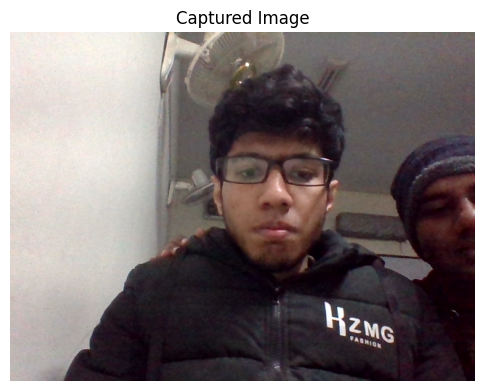

Image quality acceptable!


In [ ]:
def take_photo(filename='webcam_image.png', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = 'Capture';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getTracks().forEach(track => track.stop());
            div.remove();
            return canvas.toDataURL('image/png', quality);
        }
    ''')
    display(js)
    data = output.eval_js("takePhoto(0.8)")
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

def check_image_quality(image_path):
    image = cv2.imread(image_path)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    brightness = gray.mean()
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()

    if brightness < 50 or brightness > 200:
        print(f"Brightness ({brightness:.1f}) not ideal. Retake the photo.")
        return False
    if laplacian_var < 100:
        print(f"Sharpness ({laplacian_var:.1f}) too low. Retake the photo.")
        return False
    return True

# Loop until good photo
while True:
    clear_output(wait=True)
    print("Please take a photo using your webcam.")
    image_path = take_photo()
    image = cv2.imread(image_path)

    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Captured Image")
    plt.show()

    if check_image_quality(image_path):
        print("Image quality acceptable!")
        break
    else:
        print("Please try again.\n")


In [ ]:
# -------------------------------
# Brightness
# -------------------------------
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # Add this line to define image_rgb
gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
brightness = gray.mean()
print(f"\nAverage brightness: {brightness:.2f}")
if brightness < 50:
    print("Warning: Image is too dark.")
elif brightness > 200:
    print("Warning: Image is too bright.")
else:
    print("Brightness is good.")

# -------------------------------
# Blur / Sharpness
# -------------------------------
laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var()
print(f"Image sharpness (Laplacian variance): {laplacian_var:.2f}")
if laplacian_var < 100:
    print("Warning: Image may be blurry.")
else:
    print("Image sharpness is good.")



Average brightness: 103.67
Brightness is good.
Image sharpness (Laplacian variance): 161.42
Image sharpness is good.


In [ ]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request
import os

# Define the model path and URL
model_path = 'blaze_face_short_range.tflite'
model_url = 'https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite'

# Download the model if it doesn't exist
if not os.path.exists(model_path):
    print(f"Downloading {model_path}...")
    urllib.request.urlretrieve(model_url, model_path)
    print("Download complete.")

# Initialize MediaPipe Face Detector using the tasks API
base_options = python.BaseOptions(model_asset_path=model_path)
options = vision.FaceDetectorOptions(base_options=base_options, min_detection_confidence=0.5)
face_detector = vision.FaceDetector.create_from_options(options)

# Note: `mp_drawing` from `mediapipe.solutions.drawing_utils` is deprecated in the new API.
# Drawing functionality will need to be adapted in subsequent cells to use the new drawing utilities
# or custom drawing logic based on the `mp.tasks` output. Removing it from this cell to avoid AttributeError.

Download complete.


Face detected!


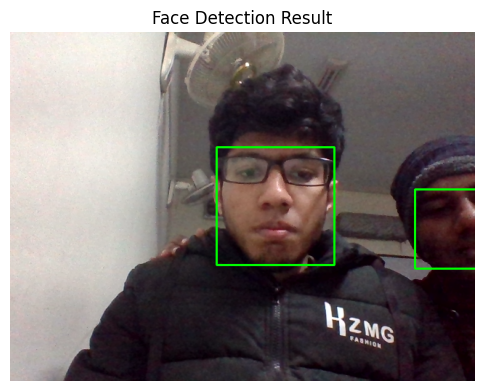

In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert the NumPy array to a MediaPipe Image object.
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

# Perform face detection.
results = face_detector.detect(mp_image)

# Create a copy of the original image to draw on
annotated_image = np.copy(image_rgb)

if results.detections:
    for detection in results.detections:
        # Get the bounding box from the detection
        bbox = detection.bounding_box
        start_point = (bbox.origin_x, bbox.origin_y)
        end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)

        # Draw the bounding box on the image
        cv2.rectangle(annotated_image, start_point, end_point, (0, 255, 0), 2) # Green rectangle, thickness 2

    print("Face detected!")
else:
    print("No face detected. Ensure your face is visible.")

plt.figure(figsize=(6,6))
plt.imshow(annotated_image)
plt.axis('off')
plt.title("Face Detection Result")
plt.show()

In [ ]:
face_shape = "Unknown"

if results.detections:
    # Use bounding box to approximate face dimensions
    detection = results.detections[0]
    bbox = detection.bounding_box # Corrected: Access bounding_box directly

    # Use width and height from the bounding box for aspect ratio calculation
    w = bbox.width
    h = bbox.height
    aspect_ratio = h / w

    if 0.9 <= aspect_ratio <= 1.1:
        face_shape = "Round"
    elif aspect_ratio > 1.2:
        face_shape = "Oval"
    elif aspect_ratio < 0.9:
        face_shape = "Square/Heart"
    else:
        face_shape = "Unknown"

print(f"Approximate Face Shape: {face_shape}")

Approximate Face Shape: Round


In [ ]:
gender_result = DeepFace.analyze(image, actions=['gender'], enforce_detection=False)
predicted_gender = gender_result[0]['dominant_gender']
print(f"Detected Gender: {predicted_gender}")

Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5


26-02-04 04:28:48 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


100%|██████████| 537M/537M [00:02<00:00, 252MB/s]


Detected Gender: Man


In [ ]:
# -------------------------------
# Personalized Hairstyle Suggestions
# -------------------------------

# --- Complete Hairstyle Dictionary ---
detailed_suggestions = {

    "Man": {
        "Oval": {
            "straight": {
                "short": ["Crew cut", "Buzz cut", "Side part", "Textured crop"],
                "medium": ["Pompadour", "Quiff", "Slick back"],
                "long": ["Medium-length layered hair", "Undercut with longer top"]
            },
            "wavy": {
                "short": ["Textured crop", "Wavy side part"],
                "medium": ["Wavy quiff", "Messy pompadour"],
                "long": ["Medium-length wavy layers"]
            },
            "curly": {
                "short": ["Short curly crop"],
                "medium": ["Curly top with fade"],
                "long": ["Medium-length curly layers"]
            }
        },

        "Round": {
            "straight": {
                "short": ["High fade with volume on top", "Textured crop with height"],
                "medium": ["Pompadour", "Side-part comb over"],
                "long": ["Medium-length layered cut with height"]
            },
            "wavy": {
                "short": ["Wavy textured crop"],
                "medium": ["Messy quiff", "Wavy side part"],
                "long": ["Layered wavy hairstyle with height"]
            },
            "curly": {
                "short": ["Curly top with fade"],
                "medium": ["Curly quiff"],
                "long": ["Curly layered hairstyle with volume"]
            }
        },

        "Square": {
            "straight": {
                "short": ["Crew cut", "Buzz cut", "Side part"],
                "medium": ["Pompadour", "Slick back"],
                "long": ["Layered medium-length hairstyle"]
            },
            "wavy": {
                "short": ["Short textured waves"],
                "medium": ["Wavy side part"],
                "long": ["Medium-length wavy layers"]
            },
            "curly": {
                "short": ["Short curly crop"],
                "medium": ["Curly textured top"],
                "long": ["Medium-length curly hairstyle"]
            }
        },

        "Rectangular": {
            "straight": {
                "short": ["Textured crop with fringe"],
                "medium": ["Side part with low volume", "Medium layered cut"],
                "long": ["Medium-length straight layers"]
            },
            "wavy": {
                "short": ["Wavy fringe cut"],
                "medium": ["Wavy medium-length hairstyle"],
                "long": ["Layered wavy haircut"]
            },
            "curly": {
                "short": ["Curly fringe style"],
                "medium": ["Curly medium-length cut"],
                "long": ["Layered curly hairstyle"]
            }
        },

        "Heart": {
            "straight": {
                "short": ["Side-swept fringe", "Textured crop"],
                "medium": ["Curtains hairstyle", "Messy quiff"],
                "long": ["Medium layered hairstyle"]
            },
            "wavy": {
                "short": ["Wavy fringe cut"],
                "medium": ["Messy wavy hairstyle"],
                "long": ["Layered wavy haircut"]
            },
            "curly": {
                "short": ["Curly fringe crop"],
                "medium": ["Curly layered cut"],
                "long": ["Medium-length curly hairstyle"]
            }
        },

        "Diamond": {
            "straight": {
                "short": ["Textured fringe haircut"],
                "medium": ["Side part", "Messy quiff"],
                "long": ["Medium-length layered hairstyle"]
            },
            "wavy": {
                "short": ["Wavy fringe cut"],
                "medium": ["Wavy side part"],
                "long": ["Layered wavy hairstyle"]
            },
            "curly": {
                "short": ["Curly textured crop"],
                "medium": ["Curly layered haircut"],
                "long": ["Medium-length curly hairstyle"]
            }
        },

        "Triangle": {
            "straight": {
                "short": ["Textured top with fade"],
                "medium": ["Quiff", "Side part"],
                "long": ["Medium layered hairstyle"]
            },
            "wavy": {
                "short": ["Wavy textured top"],
                "medium": ["Wavy quiff"],
                "long": ["Layered wavy haircut"]
            },
            "curly": {
                "short": ["Curly top with fade"],
                "medium": ["Curly quiff"],
                "long": ["Medium-length curly hairstyle"]
            }
        }
    },

    "Woman": {
        "Oval": {
            "straight": {
                "short": ["Pixie cut", "Chin-length bob"],
                "medium": ["Shoulder-length lob", "Sleek layered cut"],
                "long": ["Long straight layers", "Center-parted hair"]
            },
            "wavy": {
                "short": ["Wavy bob"],
                "medium": ["Beach waves", "Layered lob"],
                "long": ["Long loose waves"]
            },
            "curly": {
                "short": ["Curly pixie"],
                "medium": ["Curly shoulder-length cut"],
                "long": ["Long curly layers"]
            }
        },

        "Round": {
            "straight": {
                "short": ["Asymmetrical bob"],
                "medium": ["Long bob with layers"],
                "long": ["Long straight hair with face-framing layers"]
            },
            "wavy": {
                "short": ["Wavy angled bob"],
                "medium": ["Layered wavy lob"],
                "long": ["Long wavy hair with volume at crown"]
            },
            "curly": {
                "short": ["Curly bob with height"],
                "medium": ["Curly layered cut"],
                "long": ["Long curly hair with volume on top"]
            }
        },

        "Square": {
            "straight": {
                "short": ["Soft bob with layers"],
                "medium": ["Shoulder-length layered cut"],
                "long": ["Long layers with soft ends"]
            },
            "wavy": {
                "short": ["Wavy chin-length bob"],
                "medium": ["Soft wavy lob"],
                "long": ["Loose wavy layers"]
            },
            "curly": {
                "short": ["Curly bob"],
                "medium": ["Curly shoulder-length cut"],
                "long": ["Long soft curls"]
            }
        },

        "Rectangular": {
            "straight": {
                "short": ["Bob with bangs"],
                "medium": ["Layered shoulder-length cut"],
                "long": ["Long straight hair with curtain bangs"]
            },
            "wavy": {
                "short": ["Wavy bob with fringe"],
                "medium": ["Wavy shoulder-length cut"],
                "long": ["Long layered waves"]
            },
            "curly": {
                "short": ["Curly bob with bangs"],
                "medium": ["Curly layered cut"],
                "long": ["Long curly hairstyle with width"]
            }
        },

        "Heart": {
            "straight": {
                "short": ["Pixie with side bangs"],
                "medium": ["Shoulder-length layered cut"],
                "long": ["Long layers with side part"]
            },
            "wavy": {
                "short": ["Wavy bob with side fringe"],
                "medium": ["Soft wavy lob"],
                "long": ["Long wavy layers"]
            },
            "curly": {
                "short": ["Curly pixie with volume"],
                "medium": ["Curly layered bob"],
                "long": ["Long curly layers"]
            }
        },

        "Diamond": {
            "straight": {
                "short": ["Chin-length bob with fringe"],
                "medium": ["Layered lob"],
                "long": ["Long straight layers with side part"]
            },
            "wavy": {
                "short": ["Wavy bob"],
                "medium": ["Soft wavy layers"],
                "long": ["Long wavy hairstyle"]
            },
            "curly": {
                "short": ["Curly bob"],
                "medium": ["Curly layered cut"],
                "long": ["Long curly hairstyle"]
            }
        },

        "Triangle": {
            "straight": {
                "short": ["Pixie with volume"],
                "medium": ["Shoulder-length layered cut"],
                "long": ["Long layers with crown volume"]
            },
            "wavy": {
                "short": ["Wavy pixie"],
                "medium": ["Layered wavy lob"],
                "long": ["Long layered waves"]
            },
            "curly": {
                "short": ["Curly pixie"],
                "medium": ["Curly shoulder-length cut"],
                "long": ["Long curly hairstyle with volume"]
            }
        }
    }
}


# --- User Inputs ---
print("Let's personalize your hairstyle recommendations!")

# Hair texture input
hair_texture = input("Your hair texture? (straight/wavy/curly): ").strip().lower()
while hair_texture not in ["straight", "wavy", "curly"]:
    hair_texture = input("Please enter: straight, wavy, or curly: ").strip().lower()

# Hair length input
hair_length = input("Preferred hair length? (short/medium/long): ").strip().lower()
while hair_length not in ["short", "medium", "long"]:
    hair_length = input("Please enter: short, medium, or long: ").strip().lower()

# Maintenance preference
maintenance = input("Do you prefer low-maintenance or stylish/fashionable hairstyles? ").strip().lower()
while maintenance not in ["low-maintenance", "stylish", "fashionable"]:
    maintenance = input("Please enter: low-maintenance, stylish, or fashionable: ").strip().lower()

# --- Generate Personalized Recommendations ---
recommended_personalized = detailed_suggestions.get(predicted_gender, {}) \
    .get(face_shape, {}) \
    .get(hair_texture, {}) \
    .get(hair_length, ["Classic hairstyle"])

# Add maintenance-specific notes
if maintenance in ["low-maintenance"]:
    recommended_personalized = [s.replace("(stylish)", "(low-maintenance)") for s in recommended_personalized]
elif maintenance in ["stylish", "fashionable"]:
    recommended_personalized = [s.replace("(low-maintenance)", "(stylish/fashion-forward)") for s in recommended_personalized]

# --- Display Recommendations ---
print("\n🎯 Personalized Hairstyle Suggestions for You:")
for i, style in enumerate(recommended_personalized, start=1):
    print(f"{i}. {style}")


Let's personalize your hairstyle recommendations!
Your hair texture? (straight/wavy/curly): straight
Preferred hair length? (short/medium/long): short
Do you prefer low-maintenance or stylish/fashionable hairstyles? stylish

🎯 Personalized Hairstyle Suggestions for You:
1. High fade with volume on top
2. Textured crop with height


In [ ]:
feedback = input("\nDo you like these hairstyle suggestions? (yes/no): ").strip().lower()
feedback_text = "User liked the recommendations." if feedback in ['yes','y'] else "User did NOT like the recommendations."

with open("user_feedback.txt", "w") as f:
    f.write(f"Gender: {predicted_gender}\n")
    f.write(f"Face Shape: {face_shape}\n")
    f.write("Recommended Hairstyles:\n")
    for style in recommended_personalized:
        f.write(f"- {style}\n")
    f.write(f"Feedback: {feedback_text}\n")


Do you like these hairstyle suggestions? (yes/no): yes


In [ ]:
from duckduckgo_search import DDGS
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

def get_hairstyle_image(hairstyle, gender):
    query = f"{gender} {hairstyle} haircut"
    with DDGS() as ddgs:
        results = list(ddgs.images(query, max_results=1))

    if not results:
        return None

    img_url = results[0]["image"]
    img = Image.open(BytesIO(requests.get(img_url).content)).convert("RGB")
    return img


In [ ]:
def show_result(user_img, hairstyle_img, hairstyle_name):
    user_img = cv2.cvtColor(user_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(user_img)
    plt.title("Captured Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    if hairstyle_img is not None:
        plt.imshow(hairstyle_img)
        plt.title(f"Suggested Hairstyle:\n{hairstyle_name}")
    else:
        plt.text(0.5, 0.5, "No image found", ha='center')
    plt.axis("off")

    plt.show()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/tmp/ipython-input-1697439813.py:9: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS() as ddgs:
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timez

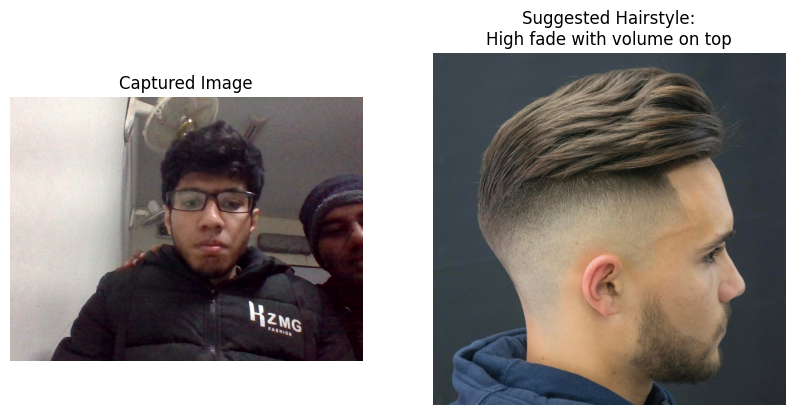

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# image is already captured and available from previous cells.

# Use already computed variables
current_gender = predicted_gender
current_face_shape = face_shape
current_hair_type = hair_texture
current_hair_length = hair_length

hairstyle = detailed_suggestions[current_gender][current_face_shape][current_hair_type][current_hair_length][0]

hairstyle_img = get_hairstyle_image(hairstyle, current_gender)
show_result(image, hairstyle_img, hairstyle)


In [ ]:
image_filename = "user_image.png"
# Ensure we convert RGB → BGR before saving for OpenCV/FPDF
image_to_save = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
cv2.imwrite(image_filename, image_to_save)


pdf = FPDF()
pdf.add_page()
pdf.set_font("Arial", 'B', 16)
pdf.cell(0, 10, "AI Hairstyle Recommendation", ln=True, align='C')
pdf.ln(10)
pdf.image(image_filename, x=50, y=30, w=100)
pdf.ln(70)
pdf.set_font("Arial", '', 12)
pdf.cell(0, 8, f"Detected Gender: {predicted_gender}", ln=True)
pdf.cell(0, 8, f"Detected Face Shape: {face_shape}", ln=True)
pdf.ln(5)
pdf.cell(0, 8, "Recommended Hairstyles:", ln=True)
for i, style in enumerate(recommended_personalized, start=1):
    pdf.cell(0, 8, f"{i}. {style}", ln=True)
pdf.ln(5)
pdf.set_font("Arial", 'I', 12)
pdf.cell(0, 8, f"User Feedback: {feedback_text}", ln=True)

pdf_filename = "hairstyle_recommendation.pdf"
pdf.output(pdf_filename)
print(f"PDF saved as {pdf_filename}")

files.download(pdf_filename)

PDF saved as hairstyle_recommendation.pdf


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# ------------------------------
# Complete Hairstyle Display & PDF Export (Local + Online)
# ------------------------------

# Install required packages (run once)
!pip install duckduckgo-search pillow fpdf

# Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from duckduckgo_search import DDGS
from PIL import Image
import requests
from io import BytesIO
from fpdf import FPDF
import tempfile

# ------------------------------
# Functions
# ------------------------------

# 1️⃣ Load local hairstyle image (Option 2)
def load_local_hairstyle_image(hairstyle_name, gender):
    filename = hairstyle_name.replace(" ", "_") + ".jpg"
    path = f"hairstyles/{gender}/{filename}"

    if not os.path.exists(path):
        return None
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# 2️⃣ Fetch online hairstyle image (Option 1)
def fetch_online_hairstyle_image(hairstyle_name, gender):
    query = f"{gender} {hairstyle_name} haircut"
    try:
        with DDGS() as ddgs:
            results = list(ddgs.images(query, max_results=1))
        if not results:
            return None
        img_url = results[0]["image"]
        response = requests.get(img_url, timeout=10)
        img = Image.open(BytesIO(response.content)).convert("RGB")
        return img
    except Exception as e:
        print("Online fetch failed:", e)
        return None

# 3️⃣ Smart image selector (try local first, then online)
def get_hairstyle_image(hairstyle_name, gender):
    img = load_local_hairstyle_image(hairstyle_name, gender)
    if img is not None:
        return img, "Local dataset"
    img = fetch_online_hairstyle_image(hairstyle_name, gender)
    if img is not None:
        return img, "Online fetch"
    return None, "Not available"

# 4️⃣ Side-by-side display
def show_result(user_img, hairstyle_img, hairstyle_name, source):
    user_img = cv2.cvtColor(user_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.imshow(user_img)
    plt.title("Captured Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    if hairstyle_img is not None:
        plt.imshow(hairstyle_img)
        plt.title(f"{hairstyle_name}\n(Source: {source})")
    else:
        plt.text(0.5, 0.5, "Image not available", ha="center")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# 5️⃣ PDF export (works with both local and online)
def export_to_pdf(user_img, hairstyle_img, gender, face_shape, hair_type, hairstyle):
    pdf = FPDF()
    pdf.add_page()

    pdf.set_font("Arial", "B", 16)
    pdf.cell(0, 10, "AI Hairstyle Recommendation Report", ln=True)

    pdf.set_font("Arial", size=12)
    pdf.ln(5)
    pdf.multi_cell(0, 8, f"""
Gender: {gender}
Face Shape: {face_shape}
Hair Type: {hair_type}
Recommended Hairstyle: {hairstyle}
""")

    # Save temporary images
    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as f1, \
         tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as f2:

        user_rgb = cv2.cvtColor(user_img, cv2.COLOR_BGR2RGB)
        cv2.imwrite(f1.name, cv2.cvtColor(user_rgb, cv2.COLOR_RGB2BGR))

        if hairstyle_img is not None:
            if isinstance(hairstyle_img, np.ndarray):
                cv2.imwrite(f2.name, cv2.cvtColor(hairstyle_img, cv2.COLOR_RGB2BGR))
            else:
                hairstyle_img.save(f2.name)

        pdf.ln(5)
        pdf.cell(0, 10, "Captured Image", ln=True)
        pdf.image(f1.name, w=80)

        if hairstyle_img is not None:
            pdf.ln(5)
            pdf.cell(0, 10, "Recommended Hairstyle", ln=True)
            pdf.image(f2.name, w=80)

    pdf.output("hairstyle_recommendation.pdf")
    print("PDF saved as hairstyle_recommendation.pdf")

# ------------------------------
# Example Usage
# ------------------------------

# `image` = captured user image (cv2 BGR)
# For demonstration, replace with your captured image variable
# image = cv2.imread("user_face.jpg")  # Example local image

# AI-derived info (from your pipeline)
gender = "Man"        # "Man" or "Woman"
face_shape = "Oval"   # e.g. "Oval", "Round", "Square"
hair_type = "straight" # "straight", "wavy", "curly"
length = "medium"      # "short", "medium", "long"

# Get recommended hairstyle
hairstyle = detailed_suggestions[gender][face_shape][hair_type][length][0]

# Get hairstyle image (Option 1 + 2 combined)
hairstyle_img, source = get_hairstyle_image(hairstyle, gender)

# Show side-by-side
show_result


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

<function __main__.show_result(user_img, hairstyle_img, hairstyle_name, source)>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

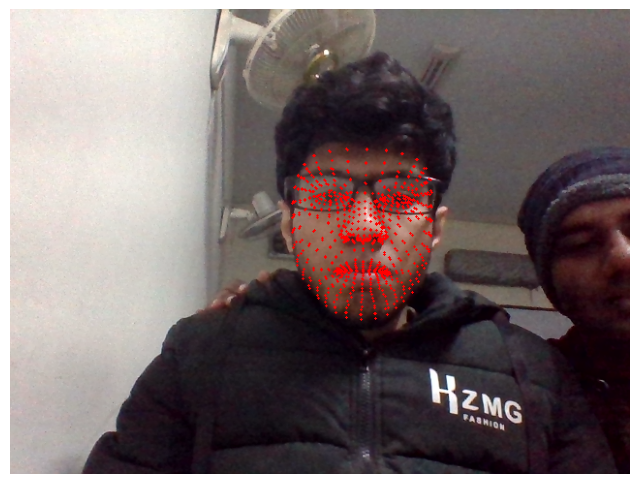

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
# -------------------------------
# Download MediaPipe Face Landmarker model
# -------------------------------
!wget -O face_landmarker.task -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task

# Get image dimensions (assuming image_rgb is defined from previous cell)
height, width, _ = image_rgb.shape

# -------------------------------
# Initialize Face Landmarker (Face Mesh)
# -------------------------------
# Use the downloaded Face Landmarker model
base_options = python.BaseOptions(model_asset_path='face_landmarker.task')

landmarker_options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)

face_mesh = vision.FaceLandmarker.create_from_options(landmarker_options)

# -------------------------------
# Run detection
# -------------------------------
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
mesh_result = face_mesh.detect(mp_image)

# -------------------------------
# Draw landmarks
# -------------------------------
if mesh_result.face_landmarks:
    for lm in mesh_result.face_landmarks[0]:
        x = int(lm.x * width)
        y = int(lm.y * height)
        cv2.circle(image_rgb, (x, y), 1, (255, 0, 0), -1)  # blue dots

# -------------------------------
# Display result
# -------------------------------
plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

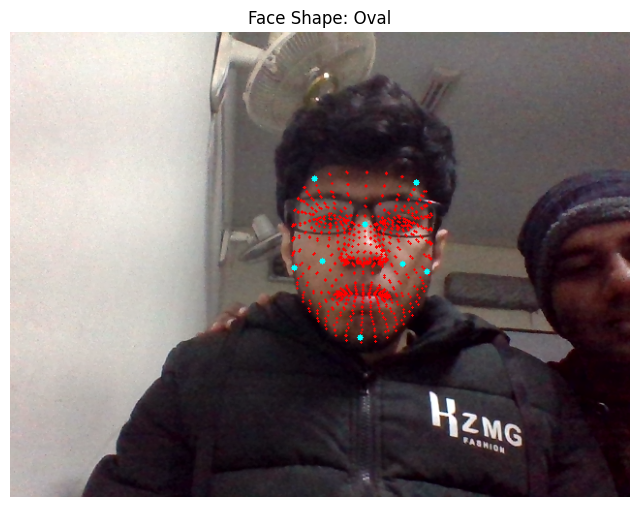

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
if mesh_result.face_landmarks:
    face_landmarks = mesh_result.face_landmarks[0] # Assuming one face

    # Approximate landmark indices for key facial points (these are based on common MediaPipe Face Mesh indices)
    # You might need to adjust these indices based on the specific requirements or different Face Mesh models.
    chin_lm = face_landmarks[152]
    jaw_left_lm = face_landmarks[205]
    jaw_right_lm = face_landmarks[425]
    cheek_left_lm = face_landmarks[132]
    cheek_right_lm = face_landmarks[361]
    forehead_left_lm = face_landmarks[103] # Upper left brow area, can be adjusted for higher forehead point
    forehead_right_lm = face_landmarks[332] # Upper right brow area
    midface_lm = face_landmarks[6] # Base of the nose, a central face point

    # Convert normalized landmarks to pixel coordinates
    chin = np.array([int(chin_lm.x * width), int(chin_lm.y * height)])
    jaw_left = np.array([int(jaw_left_lm.x * width), int(jaw_left_lm.y * height)])
    jaw_right = np.array([int(jaw_right_lm.x * width), int(jaw_right_lm.y * height)])
    cheek_left = np.array([int(cheek_left_lm.x * width), int(cheek_left_lm.y * height)])
    cheek_right = np.array([int(cheek_right_lm.x * width), int(cheek_right_lm.y * height)])
    forehead_left = np.array([int(forehead_left_lm.x * width), int(forehead_left_lm.y * height)])
    forehead_right = np.array([int(forehead_right_lm.x * width), int(forehead_right_lm.y * height)])
    midface = np.array([int(midface_lm.x * width), int(midface_lm.y * height)])

    # Draw points for visualization
    for pt in [jaw_left, jaw_right, chin, cheek_left, cheek_right, forehead_left, forehead_right, midface]:
        cv2.circle(image_rgb, tuple(pt.astype(int)), 3, (0,255,255), -1)
else:
    print("No face landmarks detected to draw specific points for face shape analysis.")

plt.figure(figsize=(8,8))
plt.imshow(image_rgb)
plt.axis('off')
plt.title(f"Face Shape: {face_shape}")
plt.show()